In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os

folder_path = '/content/drive/My Drive/Colab Notebooks/SR250Mate'

for root, dirs, files in os.walk(folder_path):
    for file in files:
        print(os.path.join(root, file))


/content/drive/My Drive/Colab Notebooks/SR250Mate/14_Still position_20250618-111131_sr250_rx0.npy
/content/drive/My Drive/Colab Notebooks/SR250Mate/7_Still position_(250,45)_20250618-105902_sr250_rx2.npy
/content/drive/My Drive/Colab Notebooks/SR250Mate/3_Still position_20250618-111255_sr250_rx1.npy
/content/drive/My Drive/Colab Notebooks/SR250Mate/2_Still position_20250618-110517_sr250_rx1.npy
/content/drive/My Drive/Colab Notebooks/SR250Mate/7_Still position_20250618-110649_sr250_rx2.npy
/content/drive/My Drive/Colab Notebooks/SR250Mate/8_Still position_20250618-110927_sr250_rx2.npy
/content/drive/My Drive/Colab Notebooks/SR250Mate/7_Still position_20250618-110649_sr250_rx1.npy
/content/drive/My Drive/Colab Notebooks/SR250Mate/8_Still position_20250618-110927_sr250_rx1.npy
/content/drive/My Drive/Colab Notebooks/SR250Mate/14_Still position_20250618-111131_sr250_rx2.npy
/content/drive/My Drive/Colab Notebooks/SR250Mate/2_Still position_20250618-110517_sr250_rx0.npy
/content/drive/My D

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import os


In [ ]:
file_dir = '/content/drive/My Drive/Colab Notebooks/SR250Mate/'
base_name = '14_Still position_20250618-111131_sr250_rx{}.npy'

# Load all three antennas data into a list using a loop
rx_data = []
for i in range(3):
    file_path = os.path.join(file_dir, base_name.format(i))
    data = np.load(file_path)
    rx_data.append(data)

# Now rx_data[0] is rx0, rx_data[1] is rx1, rx_data[2] is rx2
rx0, rx1, rx2 = rx_data

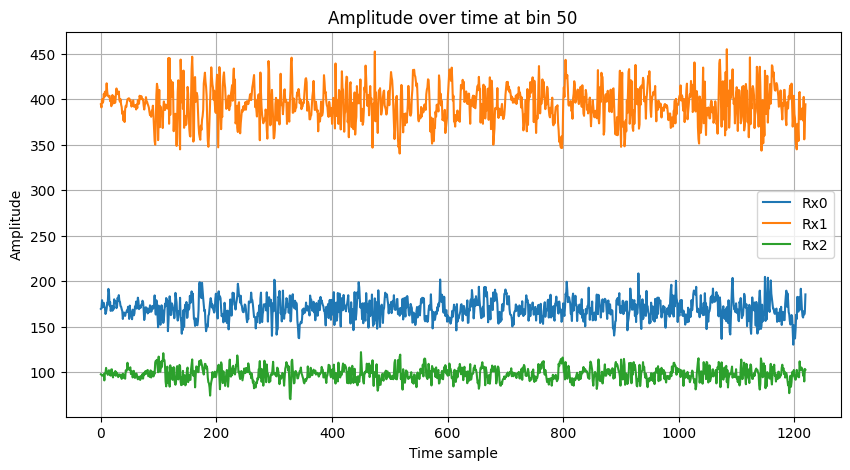

In [ ]:
# Example: choose a range bin index to plot
bin_idx = 50  # you can change this to any valid bin index

plt.figure(figsize=(10, 5))

plt.plot(np.abs(rx0[:, bin_idx]), label='Rx0')
plt.plot(np.abs(rx1[:, bin_idx]), label='Rx1')
plt.plot(np.abs(rx2[:, bin_idx]), label='Rx2')

plt.title(f'Amplitude over time at bin {bin_idx}')
plt.xlabel('Time sample')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
# Stack antennas along a new last dimension
data = np.stack((rx0, rx1, rx2), axis=-1)  # shape: (1200, 120, 3)

print(data.shape)  # should print (1200, 120, 3)


(1220, 120, 3)


(1220, 120, 3)


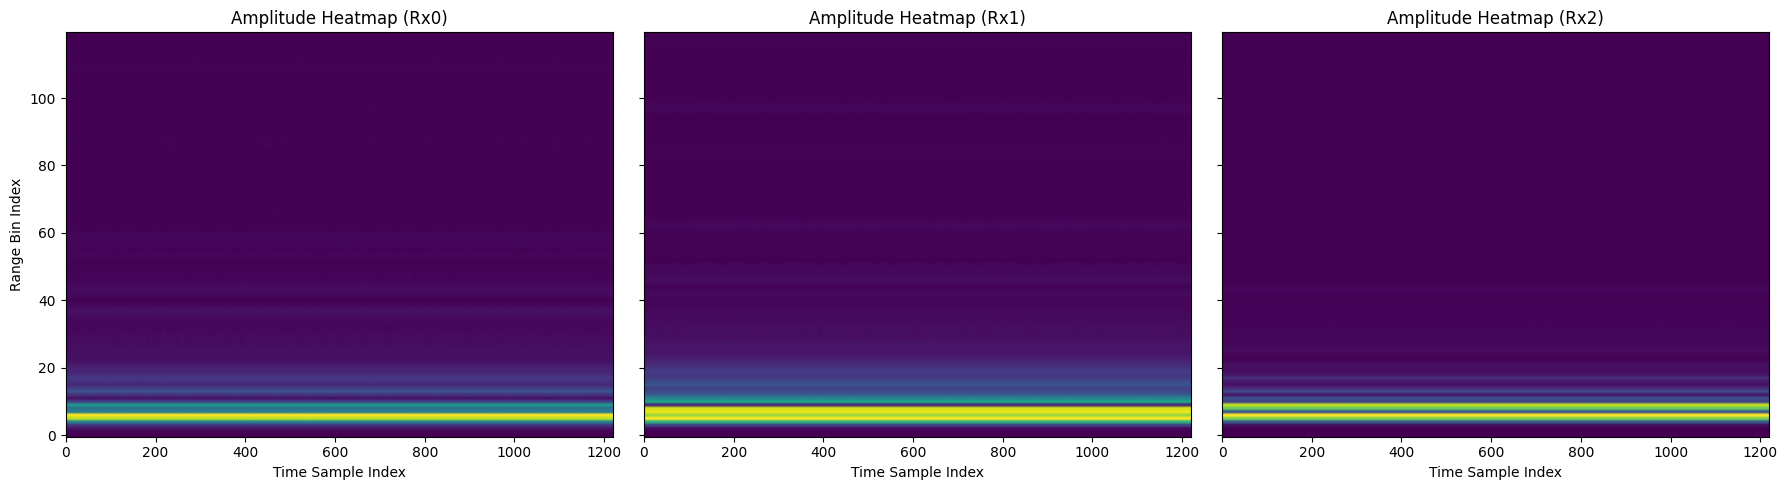

In [ ]:
# data shape: (time_samples, bins, antennas)
# Example check:
print(data.shape)  # should print (1200, 120, 3)

fig, axs = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for i in range(3):
    amplitude = np.abs(data[:, :, i])
    axs[i].imshow(amplitude.T, aspect='auto', origin='lower', cmap='viridis')
    axs[i].set_title(f'Amplitude Heatmap (Rx{i})')
    axs[i].set_xlabel('Time Sample Index')
    if i == 0:
        axs[i].set_ylabel('Range Bin Index')

plt.tight_layout()
plt.show()


In [ ]:
def preprocess_moving_average(data, W):
    """
    Apply moving average clutter removal on radar data.

    Parameters:
    - data: np.ndarray of shape (M, K, N_RX), complex raw radar signals
      M: number of time frames
      K: number of range bins
      N_RX: number of antennas
    - W: int, window size for moving average filter

    Returns:
    - cleaned_data: np.ndarray of shape (M-W+1, K, N_RX), clutter-free radar signals
    """
    M, K, N_RX = data.shape
    cleaned_frames = M - W + 1

    cleaned_data = np.zeros((cleaned_frames, K, N_RX), dtype=complex)

    for m in range(W - 1, M):
        # Compute average over last W frames (clutter estimate)
        moving_avg = np.mean(data[m-W+1:m+1, :, :], axis=0)
        # Subtract clutter from current frame
        cleaned_data[m - (W - 1), :, :] = data[m, :, :] - moving_avg

    return cleaned_data


In [ ]:
# Example window size for moving average clutter removal
W = 10  # window size

# Call the function
cleaned_data = preprocess_moving_average(data, W)

print("Original data shape:", data.shape)
print("Cleaned data shape:", cleaned_data.shape)


Original data shape: (1220, 120, 3)
Cleaned data shape: (1211, 120, 3)


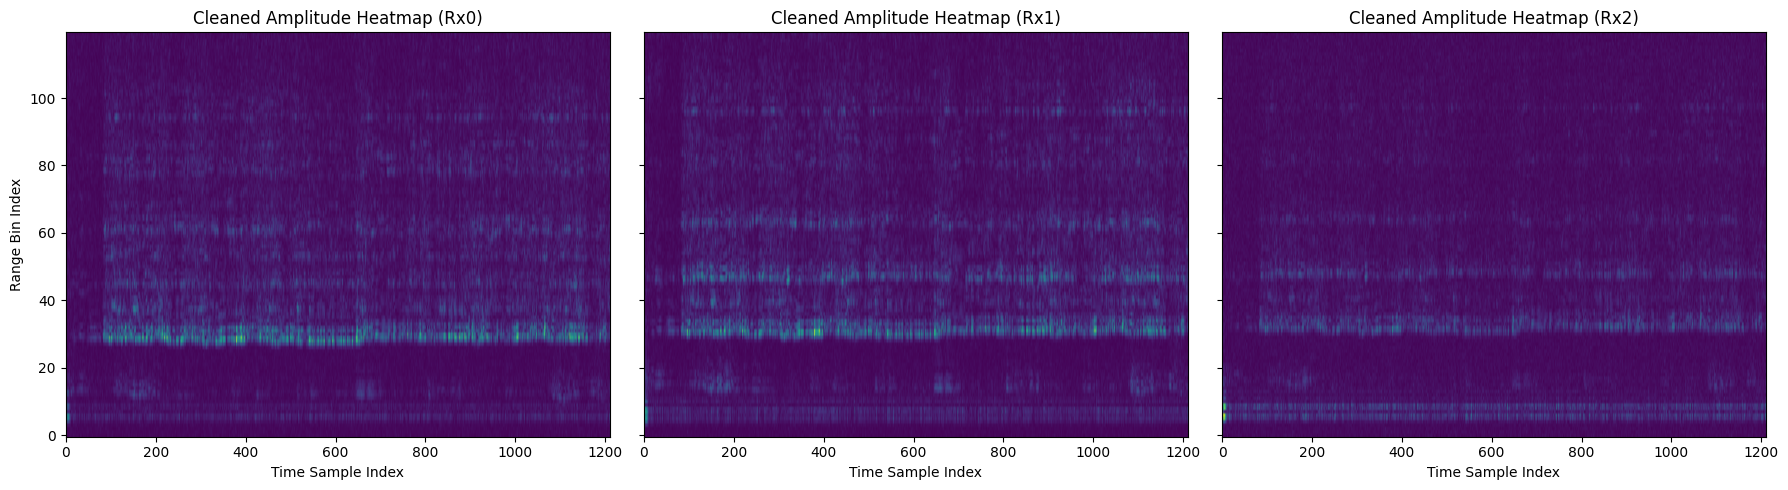

In [ ]:
# cleaned_data shape: (M-W+1, K, N_RX), e.g. (1211, 120, 3)

fig, axs = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for i in range(3):
    amplitude = np.abs(cleaned_data[:, :, i])
    axs[i].imshow(amplitude.T, aspect='auto', origin='lower', cmap='viridis')
    axs[i].set_title(f'Cleaned Amplitude Heatmap (Rx{i})')
    axs[i].set_xlabel('Time Sample Index')
    if i == 0:
        axs[i].set_ylabel('Range Bin Index')

plt.tight_layout()
plt.show()


In [ ]:
def compute_bf_weights(angle_range_rad, d, k, v_rx):
    """
    Compute beamforming weights for each angle.
    angle_range_rad: np.ndarray, angles in radians
    d: antenna spacing (meters)
    k: wave number (2*pi / wavelength)
    v_rx: number of antennas
    Returns:
    bf_weights: shape (num_angles, v_rx), complex weights
    """
    n = np.arange(v_rx)  # antenna indices
    # Using broadcasting: shape (num_angles, 1) * shape (1, v_rx)
    bf_weights = np.exp(-1j * k * d * n * np.sin(angle_range_rad[:, None]))
    return bf_weights


In [ ]:
def beamforming(bf_weights, dataCube):
    """
    dataCube: shape (slow_time, fast_time, antennas)
    bf_weights: shape (num_angles, antennas)
    Returns:
    angleDataCube: shape (slow_time, fast_time, num_angles), complex beamformed signals
    """
    slow_time, fast_time, antennas = dataCube.shape
    num_angles = bf_weights.shape[0]

    angleDataCube = np.zeros((slow_time, fast_time, num_angles), dtype=complex)

    for i in range(slow_time):
        for j in range(fast_time):
            # antenna signals at this time and range bin: shape (antennas,)
            sig = dataCube[i, j, :]
            # beamforming output for all angles at once (dot product with each bf_weights row)
            angleDataCube[i, j, :] = bf_weights @ sig

    return angleDataCube


In [ ]:
def steering_vector(N_rx, d, wavelength, angles_deg):
    """
    Compute steering vectors for a uniform linear array (ULA)

    Parameters:
    - N_rx: number of antennas
    - d: antenna spacing (meters)
    - wavelength: signal wavelength (meters)
    - angles_deg: 1D array of angles to scan (degrees)

    Returns:
    - steering_mat: shape (len(angles_deg), N_rx), complex steering vectors
    """
    angles_rad = np.deg2rad(angles_deg)
    n = np.arange(N_rx)  # antenna indices
    # Steering vector for each angle: exp(-j*2*pi*d/lambda * n * sin(theta))
    steering_mat = np.exp(-1j * 2 * np.pi / wavelength * d * np.outer(np.sin(angles_rad), n))
    return steering_mat

def perform_beamforming(cleaned_data,steering_matrix):
    """
    cleaned_data: shape (N_frames, N_bins, N_antennas)
    steering_matrix: shape (N_angles, N_antennas)
    """
    N_frames, N_bins, _ = cleaned_data.shape
    N_angles = steering_matrix.shape[0]
   # Initialize output
    beamformed_cube = np.zeros((N_frames, N_bins,N_angles), dtype=np.complex128)
    # Perform beamforming across all frames and bins
    for t in range(N_frames):
        for r in range(N_bins):
            # For time frame t and range bin r extract the vector signals across all antennas(in this case 3)
            x = cleaned_data[t, r,: ]
            # Compute beamformed signals across all angles
            beamformed_cube[t, r, :] = steering_matrix @ x  # shape (N_angles,)
    return beamformed_cube

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
c = 3e8  # speed of light in m/s
f = 7.24e9  # center frequency of TSRR250 (Hz)
wavelength = c / f
d = wavelength / 2  # half wavelength antenna spacing

# Angle scan from -45 to 45 degrees, 181 points
angles = np.linspace(-45, 45, 181)

# Get steering vectors and perform beamforming
N_rx = cleaned_data.shape[2]
steering_mat = steering_vector(N_rx, d, wavelength, angles)
beamformed_cube = perform_beamforming(cleaned_data, steering_mat)

print("Beamformed cube shape:", beamformed_cube.shape)
print("Sreering matrix shape:", steering_mat.shape)





Beamformed cube shape: (1211, 120, 181)
Sreering matrix shape: (181, 3)


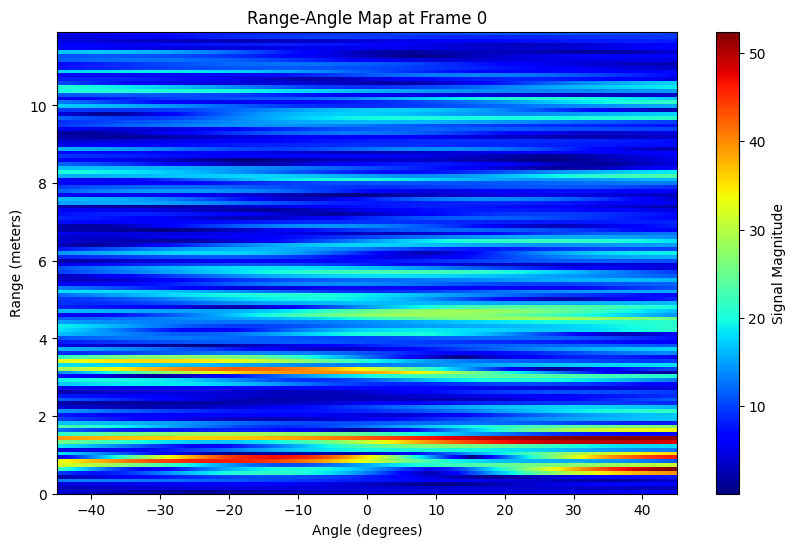

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Choose a frame index to visualize (e.g., first frame)
t = 0

# Extract magnitude (absolute value) of beamformed signals at frame t
range_angle_map = np.abs(beamformed_cube[t])  # shape: (N_bins, N_angles)

# Prepare axis values for plotting
angle_min_deg = angles[0]
angle_max_deg = angles[-1]

N_bins = range_angle_map.shape[0]
# Approximate range vector assuming uniform bins and constant resolution
range_resolution = 0.1  # meters per bin (example, adjust to your radar config)
range_vector = np.arange(N_bins) * range_resolution

plt.figure(figsize=(10, 6))
plt.imshow(range_angle_map,
           aspect='auto',
           origin='lower',
           extent=[angle_min_deg, angle_max_deg, range_vector[0], range_vector[-1]],
           cmap='jet')
plt.colorbar(label='Signal Magnitude')
plt.xlabel('Angle (degrees)')
plt.ylabel('Range (meters)')
plt.title(f'Range-Angle Map at Frame {t}')
plt.show()


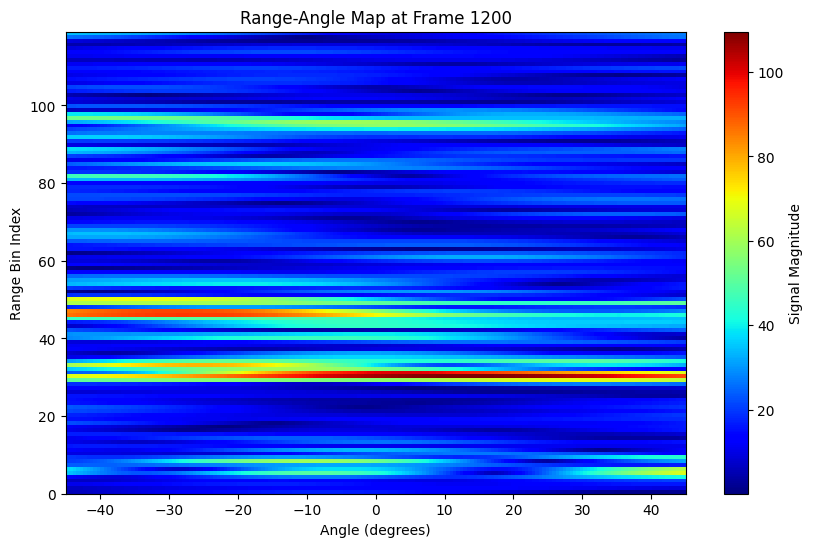

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Choose a frame index to visualize (e.g., first frame)
t = 1200

# Extract magnitude (absolute value) of beamformed signals at frame t
range_angle_map = np.abs(beamformed_cube[t])  # shape: (N_bins, N_angles)

# Use bin indices for y-axis
bin_indices = np.arange(range_angle_map.shape[0])

plt.figure(figsize=(10, 6))
plt.imshow(range_angle_map,
           aspect='auto',
           origin='lower',
           extent=[angles[0], angles[-1], bin_indices[0], bin_indices[-1]],
           cmap='jet')
plt.colorbar(label='Signal Magnitude')
plt.xlabel('Angle (degrees)')
plt.ylabel('Range Bin Index')
plt.title(f'Range-Angle Map at Frame {t}')
plt.show()


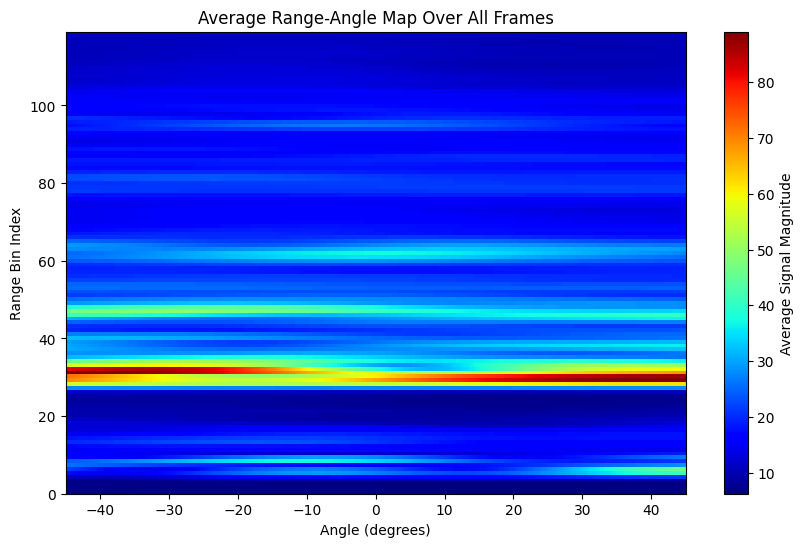

In [ ]:
# Take magnitude first
avg_map = np.mean(np.abs(beamformed_cube), axis=0)  # shape (120, 181)

plt.figure(figsize=(10, 6))
plt.imshow(avg_map,
           aspect='auto',
           origin='lower',
           extent=[angles[0], angles[-1], 0, avg_map.shape[0]-1],
           cmap='jet')
plt.colorbar(label='Average Signal Magnitude')
plt.xlabel('Angle (degrees)')
plt.ylabel('Range Bin Index')
plt.title('Average Range-Angle Map Over All Frames')
plt.show()